# 📚 Exercise Session - Week 3: Attention, Tokenization, and Transformers
**Main Topics**: Attention, Tokenization, and Transformers for Sequence-to-Sequence Modeling

**Overview**

This week’s session dives into Transformers for sequence-to-sequence (Seq2Seq) tasks, with a special focus on machine translation and attention visualization. By the end, you will have built and trained a Transformer model capable of translating text from one language to another—and you’ll see how attention helps it learn alignments across tokens.

1. [**TASK A:** Transformer Implementation](#Task-A:-Transformer-Implementation)
- Build a BPE tokenizer
- Implement a Transformer encoder-decoder model using PyTorch

2. [**TASK B:** Train a Machine Translation Model](#Task-B:-Train-a-Machine-Translation-Model)
- Use Transformer from Task A to train a machine translation model
- Visualize the cross-attention weights

3. **Optional Extensions**
- Learning Rate Scheduler: Try adding a scheduler (like Warmup or ReduceLROnPlateau) to potentially improve convergence.
- Periodic Validation: Every `m` batches or at epoch’s end, evaluate on a validation set to track loss or metrics like BLEU.
- Use PyTorch `DataLoader`

**Tips & Hints**
- **Overfitting on a Single Example**: If your model cannot easily learn one sample to near-perfect accuracy, it often indicates an implementation bug or mismatch in shapes/masks.
- **Masking**: Pay careful attention to causal masks in the decoder, ensuring the model does not see future tokens.
- **Debugging**: Print shapes and partial outputs, or watch the attention scores to confirm they behave as expected.


> **By the end of the session you will be able to:**
> - ✅  Implement an encoder-decoder Transformer model using PyTorch
> - ✅  Train your model on a machine translation corpus
> - ✅  Understand attention mechanism within the Transformer architecture
> - ✅  Be more interested in NLP 😉


**Note**: This notebook is intended to be run with a GPU. If you do not have access to one, consider using [Google Colab](https://colab.research.google.com).

## Task A: Transformer Implementation

**Quick Reminder**
We will be implementing the following encoder-decoder transformer architecture following the original [Attention is All You Need](https://arxiv.org/abs/1706.03762) paper!

![Transformer Architecture](transformer_arch.png)

In this part, you will implement an encoder-decoder Transformer model using [Pytorch](https://pytorch.org/)

In [1]:
!pip install datasets
!pip install seaborn
!pip install tokenizers transformers torch

# Transformer Architecture

In [2]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# For reproducibility
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"

        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        # These layers transform the input embeddings to queries, keys, and values
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)
        self.key_proj   = nn.Linear(hidden_dim, hidden_dim)
        self.value_proj = nn.Linear(hidden_dim, hidden_dim)

        # Final projection after concatenating heads
        self.out_proj   = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: [batch_size, seq_len, hidden_dim]
        mask: [batch_size, 1, seq_len, seq_len] or None (optional)

        returns:
          - output: [batch_size, seq_len, hidden_dim]
          - attn_weights: [batch_size, num_heads, seq_len, seq_len]
        """
        batch_size = query.size(0)

        # 1) Linear projections
        # TODO: project query, key, and value via the layers: self.query_proj, self.key_proj, self.value_proj
        # shape after projection: [batch_size, seq_len, hidden_dim]
        Q = self.query_proj(query)
        K = self.key_proj(key)
        V = self.value_proj(value)

        #MULTI-HEAD ATTENTION  - VERY IMPORTANT, MAKE SURE YOU UNDERSTAND THIS WELL, FOR INTERVIEWS ETC
        # EXAM CONTAINS QUESTIONS ON EXERCISES TOO


        # 2) Split into multiple heads
        # We want shape: [batch_size, num_heads, seq_len, head_dim]
        # TODO: reshape the Q, K, V so that we chunk hidden_dim into (num_heads, head_dim)
        Q = torch.swapaxes(torch.reshape(Q, (Q.size(0), Q.size(1), self.num_heads, self.head_dim)), 1 ,2)
        K = torch.swapaxes(torch.reshape(K, (K.size(0), K.size(1), self.num_heads, self.head_dim)), 1 ,2)
        V = torch.swapaxes(torch.reshape(V, (V.size(0), V.size(1), self.num_heads, self.head_dim)), 1 ,2)

        # 3) Scaled dot-product attention
        #    attention_scores = Q x K^T / sqrt(head_dim)
        #    then apply optional mask (if not None)
        #    then softmax, then dropout, then multiply by V

        # TODO: compute attention_scores
        # attention_scores shape: [batch_size, num_heads, seq_len, seq_len]
        attention_scores = Q @ K.swapaxes(2, 3) / math.sqrt(self.head_dim)

        # TODO: apply mask if given
        if mask is not None:
          attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))

        # TODO: normalize attention_scores
        attention_scores = torch.softmax(attention_scores, dim=-1)

        # TODO: compute attention_output
        # shape: [batch_size, num_heads, seq_len, head_dim]
        attention_output = attention_scores @ V

        # 4) Concat heads
        # We want shape: [batch_size, seq_len, hidden_dim]
        # (i.e. combine num_heads and head_dim back into hidden_dim)
        attention_output = torch.swapaxes(attention_output, 1, 2).contiguous()
        attention_output = torch.reshape(attention_output, (attention_output.size(0), attention_output.size(1), attention_output.size(2) * attention_output.size(3)))

        # 5) Final linear projection
        output = self.out_proj(attention_output)

        return output, attention_scores  # (attn_weights = normalized_weights for visualization)

In [4]:
# Create dummy inputs [batch_size, seq_len, hidden_dim]
q_test = torch.randn(16, 10, 512)
k_test = torch.randn(16, 10, 512)
v_test = torch.randn(16, 10, 512)

# Initialize and run
mha = MultiHeadAttention(hidden_dim=512, num_heads=8)
output, weights = mha(q_test, k_test, v_test)
print(output.size())
print(weights.size())

torch.Size([16, 10, 512])
torch.Size([16, 8, 10, 10])


In [5]:
class EncoderLayer(nn.Module):
    def __init__(self, hidden_dim, num_heads, intermediate_size, dropout=0):
        super(EncoderLayer, self).__init__()

        self.self_attn = MultiHeadAttention(hidden_dim, num_heads, dropout)
        self.linear1   = nn.Linear(hidden_dim, intermediate_size)
        self.linear2   = nn.Linear(intermediate_size, hidden_dim)
        self.norm1     = nn.LayerNorm(hidden_dim)
        self.norm2     = nn.LayerNorm(hidden_dim)
        self.dropout1  = nn.Dropout(dropout)
        self.dropout2  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # x shape: [batch_size, seq_len, hidden_dim]

        # 1) Multi-head self-attention
        attn_output, _ = self.self_attn(x, x, x, mask=mask)
        x = x + attn_output  # residual
        x = self.norm1(x)

        # 2) Feed-forward
        ff_output = self.linear2(F.relu(self.linear1(x)))
        x = x + ff_output  # residual
        x = self.norm2(x)

        return x

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DecoderLayer(nn.Module):
    def __init__(self, hidden_dim, num_heads, intermediate_size, dropout=0):
        super(DecoderLayer, self).__init__()

        # Multi-Head Attention Layers
        self.self_attn = MultiHeadAttention(hidden_dim, num_heads, dropout)   # Students already have MHA
        self.cross_attn = MultiHeadAttention(hidden_dim, num_heads, dropout)

        # Feed-Forward Layers
        self.linear1 = nn.Linear(hidden_dim, intermediate_size)
        self.linear2 = nn.Linear(intermediate_size, hidden_dim)

        # LayerNorms
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.norm3 = nn.LayerNorm(hidden_dim)


    def forward(self, x, enc_output, tgt_mask=None, cross_attn_mask=None):
        """
        Args:
            x: [batch_size, tgt_seq_len, hidden_dim] -- decoder input embeddings
            enc_output: [batch_size, src_seq_len, hidden_dim] -- encoder output
            tgt_mask: mask for target self-attention (e.g., causal + padding)
            cross_attn_mask: mask for encoder-decoder attention (padding mask for source)
        Returns:
            x: [batch_size, tgt_seq_len, hidden_dim] -- updated decoder features
            attn_weights: attention weights from cross-attention (for visualization, etc.)
        """

        attn_output, _ = self.self_attn(x, x, x, mask=tgt_mask)
        x = x + attn_output
        x = self.norm1(x)

        # 1) TODO: Implement cross-attention with encoder output
        #    - Query = x (decoder), Key/Value = enc_output
        #    - residual connection + self.norm2
        cross_attn, cross_attn_weights = self.cross_attn(x, enc_output, enc_output, mask=cross_attn_mask)
        x = x + cross_attn
        x = self.norm2(x)

        # 2) TODO: Implement feed-forward sub-layer
        #    - pass x through self.linear1, then an activation (e.g., F.relu)
        #    - then self.linear2
        #    - Add residual + self.norm3
        ff_output = self.linear2(F.relu(self.linear1(x)))
        x = x + ff_output  # residual
        x = self.norm3(x)

        # TODO: return final x and the cross-attention weights
        return x, cross_attn_weights


In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_heads, intermediate_size, num_layers, max_len=1024, dropout=0):
        super(Encoder, self).__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.pos_encoding = nn.Embedding(max_len, hidden_dim)
        self.layers = nn.ModuleList([
            EncoderLayer(hidden_dim, num_heads, intermediate_size, dropout) for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask=None):
        """
        src: [batch_size, src_seq_len]
        src_mask: (optional)
        """
        x = self.embedding(src) * math.sqrt(self.hidden_dim)
        seq_len = src.size(1)
        positions = torch.arange(0, seq_len, device=src.device).unsqueeze(0)

        # TODO: Add positional encoding to the input embeddings
        x = x + self.pos_encoding(positions)
        x = self.dropout(x)

        # TODO: Implement the forward pass through the encoder layers
        for layer in self.layers:
          x = layer(x, src_mask)

        return x  # shape: [batch_size, src_seq_len, hidden_dim]


class Decoder(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_heads, intermediate_size, num_layers, max_len=1024, dropout=0):
        super(Decoder, self).__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.pos_encoding = nn.Embedding(max_len, hidden_dim)
        self.layers = nn.ModuleList([
            DecoderLayer(hidden_dim, num_heads, intermediate_size, dropout) for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt, enc_output, tgt_mask=None, cross_attn_mask=None):
        """
        tgt: [batch_size, tgt_seq_len]
        enc_output: [batch_size, src_seq_len, hidden_dim]
        """
        x = self.embedding(tgt) * math.sqrt(self.hidden_dim)
        seq_len = tgt.size(1)
        positions = torch.arange(0, seq_len, device=tgt.device).unsqueeze(0)
        # TODO: Add positional encoding to the input embeddings
        x = x + self.pos_encoding(positions)
        x = self.dropout(x)

        attn_weights = None
        for layer in self.layers:
            x, attn_weights = layer(x, enc_output, tgt_mask=tgt_mask, cross_attn_mask=cross_attn_mask)

        # Final projection to vocabulary
        logits = self.out_proj(x)  # [batch_size, tgt_seq_len, vocab_size]
        return logits, attn_weights

In [8]:
import torch

def build_causal_mask(seq_len, device=None):
    """
    Returns a 2D causal mask of shape [seq_len, seq_len],
    where True means 'allowed to attend' and False means 'disallowed'.
    """
    return torch.tril(torch.ones((seq_len, seq_len), dtype=torch.bool, device=device))

def expand_causal_mask(causal_2d, batch_size, num_heads):
    # causal_2d: shape [seq_len, seq_len]
    # expand to [batch_size, num_heads, seq_len, seq_len]
    causal_4d = causal_2d.unsqueeze(0).unsqueeze(0)  # => [1,1,seq_len,seq_len]
    causal_4d = causal_4d.expand(batch_size, num_heads, causal_2d.size(0), causal_2d.size(1))
    return causal_4d

def expand_padding_mask(pad_mask_2d, num_heads):
    # pad_mask_2d: shape [batch_size, seq_len], 1 = valid, 0 = pad
    # step 1) Convert to bool if needed
    pad_mask_bool = pad_mask_2d.bool()  # shape [batch_size, seq_len]
    # step 2) unsqueeze => [batch_size, 1, 1, seq_len]
    pad_mask_4d = pad_mask_bool.unsqueeze(1).unsqueeze(2)
    # step 3) broadcast across the query dimension
    batch_size, _, _, seq_len = pad_mask_4d.shape
    pad_mask_4d = pad_mask_4d.expand(batch_size, num_heads, seq_len, seq_len)
    return pad_mask_4d


def build_decoder_mask(
    pad_mask_2d: torch.Tensor,
    num_heads: int
):
    """
    Combine the target padding mask with the causal mask
    to produce a final decoder mask of shape:
    [batch_size, num_heads, seq_len, seq_len],
    where True means 'allowed', False means 'masked out'.
    """
    device = pad_mask_2d.device
    batch_size, seq_len = pad_mask_2d.shape

    # 1) Build the 2D causal mask
    causal_2d = build_causal_mask(seq_len, device=device)

    # 2) Expand to 4D
    causal_4d = expand_causal_mask(causal_2d, batch_size, num_heads)

    # 3) Expand the padding mask to 4D
    pad_4d = expand_padding_mask(pad_mask_2d, num_heads)

    # 4) Final mask = causal AND pad
    final_mask = causal_4d & pad_4d  # shape [batch_size, num_heads, seq_len, seq_len]
    return final_mask


In [9]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, hidden_dim=512, num_heads=8, intermediate_size=2048,
                 num_layers=6, dropout=0):
        super(Transformer, self).__init__()
        self.num_heads = num_heads
        self.encoder = Encoder(src_vocab_size, hidden_dim, num_heads, intermediate_size, num_layers, dropout=dropout)
        self.decoder = Decoder(tgt_vocab_size, hidden_dim, num_heads, intermediate_size, num_layers, dropout=dropout)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, cross_attn_mask=None):

        if src_mask is not None:
            src_mask = src_mask[:, None, None, :]
            src_mask = src_mask.expand(-1, -1, src_mask.size(-1), -1)

        tgt_mask = build_decoder_mask(tgt_mask, num_heads=self.num_heads)

        enc_output = self.encoder(src, src_mask)
        logits, attn_weights = self.decoder(tgt, enc_output, tgt_mask, cross_attn_mask)
        return logits, attn_weights

In [10]:
# 1. Define small hyperparameters for testing
src_vocab = 100
tgt_vocab = 100
batch_size = 2
src_len = 5
tgt_len = 7

# 2. Create the model
model = Transformer(
    src_vocab_size=src_vocab,
    tgt_vocab_size=tgt_vocab,
    num_layers=2,
    hidden_dim=128,
    num_heads=4
)

# 3. Generate dummy source and target sequences (integer IDs)
src_data = torch.randint(0, src_vocab, (batch_size, src_len))
tgt_data = torch.randint(0, tgt_vocab, (batch_size, tgt_len))

src_mask = torch.ones(batch_size, src_len)
tgt_mask = torch.ones(batch_size, tgt_len)

# 5. Run the Forward Pass
# Note: Ensure build_decoder_mask is defined in your environment!
logits, attn_weights = model(src_data, tgt_data, src_mask=src_mask, tgt_mask=tgt_mask)
# 6. Check the Outputs
print(f"Logits shape: {logits.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

Logits shape: torch.Size([2, 7, 100])
Attention weights shape: torch.Size([2, 4, 7, 5])


## Task B: Train a Machine Translation Model

First, you need to download the French-English translation dataset using [this link](https://drive.google.com/file/d/1cPKNjpU7PiqA33GzV0yICwDjZ_0ysKjO/view?usp=sharing) or using the `gdown` command below.

In [11]:
!gdown 1cPKNjpU7PiqA33GzV0yICwDjZ_0ysKjO
!unzip wmt14_fr_en.zip

Downloading...
From: https://drive.google.com/uc?id=1cPKNjpU7PiqA33GzV0yICwDjZ_0ysKjO
To: /content/wmt14_fr_en.zip
100% 15.2M/15.2M [00:00<00:00, 51.7MB/s]
Archive:  wmt14_fr_en.zip
   creating: wmt14_fr_en/
  inflating: wmt14_fr_en/.DS_Store   
  inflating: __MACOSX/wmt14_fr_en/._.DS_Store  
  inflating: wmt14_fr_en/dataset_dict.json  
   creating: wmt14_fr_en/test/
   creating: wmt14_fr_en/train/
   creating: wmt14_fr_en/validation/
  inflating: wmt14_fr_en/test/state.json  
  inflating: wmt14_fr_en/test/dataset_info.json  
  inflating: wmt14_fr_en/test/data-00000-of-00001.arrow  
  inflating: wmt14_fr_en/train/state.json  
  inflating: wmt14_fr_en/train/dataset_info.json  
  inflating: wmt14_fr_en/train/data-00000-of-00001.arrow  
  inflating: wmt14_fr_en/validation/state.json  
  inflating: wmt14_fr_en/validation/dataset_info.json  
  inflating: wmt14_fr_en/validation/data-00000-of-00001.arrow  


In [12]:
import torch
import numpy as np
from datasets import load_from_disk

# Load the dataset
dataset = load_from_disk("wmt14_fr_en")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 100000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 3003
    })
})


### Build a BPE Tokenizer

Implement your own tokenizer pipeline instead of using the fully provided version.

**What you must implement in the next code cell:**
1. Text normalization function used before BPE training.
2. A robust batch iterator that yields lists of normalized strings.
3. BPE training configuration with meaningful hyperparameters.
4. Save and reload your tokenizer in Hugging Face fast-tokenizer format.

**Hard-mode constraints:**
- Keep special tokens exactly as: `<pad>`, `<unk>`, `<s>`, `</s>`.
- Enforce a fixed max sequence length during encoding steps later in the notebook.
- Add at least 3 sanity checks (e.g., BOS/EOS insertion, unknown token behavior, round-trip decode quality).

**Expected output before training the Transformer:**
- A working `hf_tokenizer` object.
- Printed diagnostics showing your sanity checks passed.


In [13]:
from tokenizers import ByteLevelBPETokenizer
import random
import unicodedata


def normalize_for_bpe(text):
    """
    TODO: implement normalization for tokenizer training.

    Requirements:
    - Normalize Unicode to NFKC.
    - Strip leading/trailing whitespace.
    - Collapse repeated internal whitespace to a single space.
    - Return a string.
    """
    return ' '.join(unicodedata.normalize('NFKC', text).strip().split())


def batch_iterator(dataset, batch_size=1000, shuffle=False, seed=42):
    """
    TODO: yield batches (list[str]) for tokenizer training.

    Requirements:
    - Optionally shuffle in a reproducible way when shuffle=True.
    - Normalize every string with normalize_for_bpe.
    - Skip empty strings after normalization.
    - Yield only non-empty batches.
    """
    data = dataset.copy()
    if shuffle:
      random.seed(seed)
      random.shuffle(data)
    batch = []
    for text in data:
        norm_str = normalize_for_bpe(text)
        if norm_str:
          if len(batch) >= batch_size:
            yield batch
            batch=[]
          batch.append(norm_str)
    if batch:
      yield batch

# TODO: Build a balanced bilingual training corpus.
fr_training_set = [example["translation"]["fr"] for example in dataset['train']]
en_training_set = [example["translation"]["en"] for example in dataset['train']]
training_set = fr_training_set + en_training_set


# TODO: Initialize tokenizer
tokenizer = ByteLevelBPETokenizer()


# TODO: Train from iterator
# Constraints:
# - vocab_size must be in [16_000, 40_000]
# pad to fit the sequences that are smaller than the max sequence length in a batch i guess
# s and /s are sentence delimiters
# - include special tokens exactly in this order: ["<pad>", "<unk>", "<s>", "</s>"]
# - set min_frequency >= 2
tokenizer.train_from_iterator(
    iterator=batch_iterator(training_set),
    vocab_size=32000,
    min_frequency=2,
    special_tokens=["<pad>", "<unk>", "<s>", "</s>"],
)


# TODO: Save tokenizer to this exact path
tokenizer.save("my_bytelevel_tokenizer.json")


In [14]:
# Load the tokenizer
from transformers import PreTrainedTokenizerFast


# TODO: Create a fast tokenizer wrapper from your saved tokenizer file.
# Required tokens: bos=<s>, eos=</s>, unk=<unk>, pad=<pad>
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file="my_bytelevel_tokenizer.json",
    bos_token="<s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>"

)


# TODO: run sanity checks
# 1) Encode with add_special_tokens=True
# 2) Verify pad token id is not None.
# 3) Decode and inspect token boundaries.
# space is delimited by a unicode character as well as tabs. unicode+f means that is a start of new word
sample = "The   quick\tbrown fox"
encoded_input = hf_tokenizer.encode(sample, add_special_tokens=True)
print(hf_tokenizer.pad_token_id is None)
decoded_tokens = hf_tokenizer.convert_ids_to_tokens(encoded_input)
decoded_text = hf_tokenizer.decode(encoded_input)

print(encoded_input)
print(decoded_tokens)
print(decoded_text)

False
[440, 224, 224, 8706, 201, 13031, 1721, 290, 3289]
['The', 'Ġ', 'Ġ', 'Ġquick', 'ĉ', 'bro', 'wn', 'Ġf', 'ox']
The   quick	brown fox


### Define Hyperparameters

In [15]:
# Training parameters
epochs = 2
batch_size = 16
max_len = 256
learning_rate = 1e-4

# Model parameters
# hidden dim vs intermediate size: hidden dim is the size of the input/output of each layer, intermediate size is the size of the feed-forward layer in the middle of each encoder/decoder layer. intermediate size is usually 4x hidden dim
hidden_dim = 512
num_heads = 8
intermediate_size = 2048
num_layers = 4

### Training Loop

In [16]:
# Initialize the model
model = Transformer(
    src_vocab_size=hf_tokenizer.vocab_size,
    tgt_vocab_size=hf_tokenizer.vocab_size,
    num_layers=num_layers,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    intermediate_size=intermediate_size
)
model.to(device)

print(f"> Number of parameters in the model: {sum(p.numel() for p in model.parameters()):,}")

num_batches = int(np.ceil(len(dataset['train']) / batch_size))

loss_fn = nn.CrossEntropyLoss(ignore_index=hf_tokenizer.pad_token_id)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []

model.train()
for epoch_num in range(epochs):

    for batch_idx in range(num_batches):

        train_batch = dataset['train'][batch_idx * batch_size: (batch_idx + 1) * batch_size]['translation']

        src_train = [train_batch[i]['fr'] for i in range(len(train_batch))]
        tgt_train = [train_batch[i]['en'] for i in range(len(train_batch))]

        src_tokens = hf_tokenizer(src_train, return_tensors='pt', padding=True, truncation=True, max_length=max_len).to(device)
        tgt_tokens = hf_tokenizer(tgt_train, return_tensors='pt', padding=True, truncation=True, max_length=max_len).to(device)

        # Prepend BOS token to target
        tgt_tokens["input_ids"] = torch.cat([
            torch.full_like(tgt_tokens["input_ids"][:, :1], hf_tokenizer.bos_token_id),
            tgt_tokens["input_ids"][:, :-1]
        ], dim=1)

        logits, _ = model(
            src=src_tokens['input_ids'],
            tgt=tgt_tokens["input_ids"],
            src_mask=src_tokens["attention_mask"],
            tgt_mask=tgt_tokens["attention_mask"],
        )

        # shift labels to the right
        labels = tgt_tokens["input_ids"][:, 1:].contiguous()
        logits = logits[:, :-1].contiguous()

        optimizer.zero_grad()
        loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch_num}, Batch {batch_idx}, Loss: {loss.item()}", flush=True)
        train_losses.append(loss.item())

        # if (batch_idx+1) % 200 == 0:
        #     print("Saving model...")
        #     torch.save(model.state_dict(), "transformer_model.pt")

    print(f"Epoch {epoch_num}, Loss: {np.mean(train_losses):.4f}")

torch.save(model.state_dict(), "transformer_model.pt")
print("Training complete!")

Streaming output truncated to the last 5000 lines.
Epoch 1, Batch 1252, Loss: 4.9079742431640625
Epoch 1, Batch 1253, Loss: 4.81347131729126
Epoch 1, Batch 1254, Loss: 5.3861894607543945
Epoch 1, Batch 1255, Loss: 4.915136337280273
Epoch 1, Batch 1256, Loss: 5.282837867736816
Epoch 1, Batch 1257, Loss: 4.564149856567383
Epoch 1, Batch 1258, Loss: 4.7422285079956055
Epoch 1, Batch 1259, Loss: 4.8901166915893555
Epoch 1, Batch 1260, Loss: 4.688318252563477
Epoch 1, Batch 1261, Loss: 5.220975875854492
Epoch 1, Batch 1262, Loss: 5.266915321350098
Epoch 1, Batch 1263, Loss: 4.916234016418457
Epoch 1, Batch 1264, Loss: 4.9156904220581055
Epoch 1, Batch 1265, Loss: 5.068130016326904
Epoch 1, Batch 1266, Loss: 5.270992755889893
Epoch 1, Batch 1267, Loss: 5.220834255218506
Epoch 1, Batch 1268, Loss: 5.150254726409912
Epoch 1, Batch 1269, Loss: 4.835598468780518
Epoch 1, Batch 1270, Loss: 4.995473861694336
Epoch 1, Batch 1271, Loss: 5.0279083251953125
Epoch 1, Batch 1272, Loss: 4.988683700561523

### Plot Training Loss Curve

Text(0.5, 1.0, 'Training Loss')

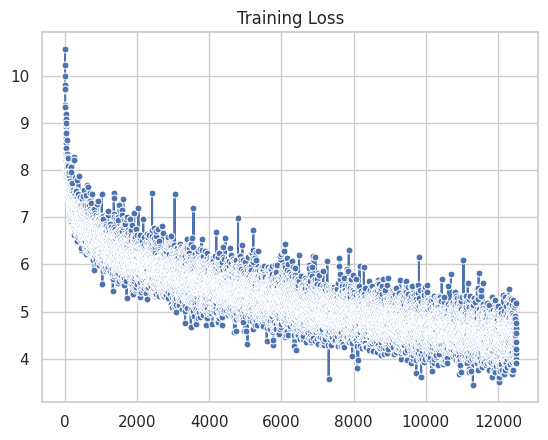

In [17]:
# Plot loss
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.lineplot(x=range(len(train_losses)), y=train_losses, marker='o', markersize=5)
plt.title("Training Loss")

### Generate Some Examples

Generate using greedy decoding. You will learn more about it in class later in the semester.

You can either use the model you trained, or a model we provide hosted on HuggingFace [here](https://huggingface.co/bkhmsi/epfl-cs552-translation-fr-en) for prediction and attention weight visualization.

The model was trained using the following configuration
```
{
    "src_vocab_size": 32000,
    "tgt_vocab_size": 32000,
    "max_seq_len": 512,
    "num_heads": 8,
    "num_layers": 8,
    "hidden_dim": 1024,
    "intermediate_size": 2048
    "epochs": 20,
    "batch_size": 64
    "learning_rate": 1e-4
}
```

In [18]:
# Load the model we provide

import os
import json
from huggingface_hub import hf_hub_download

hf_model_path = hf_hub_download(
    repo_id="bkhmsi/epfl-cs552-translation-fr-en",
    filename="pytorch_model.bin"
)

state_dict = torch.load(hf_model_path, map_location="cpu")

config = {
    "src_vocab_size": 32000,
    "tgt_vocab_size": 32000,
    "num_heads": 8,
    "num_layers": 8,
    "hidden_dim": 1024,
    "intermediate_size": 2048
}

num_heads = config["num_heads"]

model = Transformer(**config)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

hf_tokenizer_path = hf_hub_download(
    repo_id="bkhmsi/epfl-cs552-translation-fr-en",
    filename="tokenizer.json",
)

hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=hf_tokenizer_path,
    bos_token="<s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/1.07G [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [19]:
# or load the model you trained

model = Transformer(
    src_vocab_size=hf_tokenizer.vocab_size,
    tgt_vocab_size=hf_tokenizer.vocab_size,
    num_layers=num_layers,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    intermediate_size=intermediate_size
)
model.to(device)

state_dict = torch.load("transformer_model.pt")
print(state_dict.keys())
model.load_state_dict(state_dict)
model.eval()

odict_keys(['encoder.embedding.weight', 'encoder.pos_encoding.weight', 'encoder.layers.0.self_attn.query_proj.weight', 'encoder.layers.0.self_attn.query_proj.bias', 'encoder.layers.0.self_attn.key_proj.weight', 'encoder.layers.0.self_attn.key_proj.bias', 'encoder.layers.0.self_attn.value_proj.weight', 'encoder.layers.0.self_attn.value_proj.bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.linear1.weight', 'encoder.layers.0.linear1.bias', 'encoder.layers.0.linear2.weight', 'encoder.layers.0.linear2.bias', 'encoder.layers.0.norm1.weight', 'encoder.layers.0.norm1.bias', 'encoder.layers.0.norm2.weight', 'encoder.layers.0.norm2.bias', 'encoder.layers.1.self_attn.query_proj.weight', 'encoder.layers.1.self_attn.query_proj.bias', 'encoder.layers.1.self_attn.key_proj.weight', 'encoder.layers.1.self_attn.key_proj.bias', 'encoder.layers.1.self_attn.value_proj.weight', 'encoder.layers.1.self_attn.value_proj.bias', 'encoder.layers.1.s

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(32000, 512)
    (pos_encoding): Embedding(1024, 512)
    (layers): ModuleList(
      (0-3): 4 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (query_proj): Linear(in_features=512, out_features=512, bias=True)
          (key_proj): Linear(in_features=512, out_features=512, bias=True)
          (value_proj): Linear(in_features=512, out_features=512, bias=True)
          (out_proj): Linear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0, inplace=False)
        (dropout2): Dropout(p=0, inplace=False)
      )
    )
    (dropout): Dropout(p=0, inplace=False)
  )
  (decoder): Decoder(
    (e

In [20]:
src_val = [dataset['train'][i]['translation']['fr'] for i in range(5)]
tgt_val = [dataset['train'][i]['translation']['en'] for i in range(5)]

src_tokens_val = hf_tokenizer(src_val, return_tensors='pt', padding=True, truncation=True, max_length=max_len).to(device)

model.eval()
with torch.no_grad():
    for i in range(5):
        # Prepare inputs
        src = src_tokens_val['input_ids'][i].unsqueeze(0).to(device)
        tgt = torch.tensor([[hf_tokenizer.bos_token_id]], dtype=torch.long, device=device)

        # Greedy decode up to max_len
        for step in range(max_len):
            # Create tgt padding mask
            tgt_mask = torch.ones_like(tgt).bool().to(device)

            # Forward pass
            logits, _ = model(src, tgt, tgt_mask=tgt_mask)

            # Get the most probable token at the current step
            next_token = logits[:, -1, :].argmax(dim=-1)

            # Append
            tgt = torch.cat([tgt, next_token.unsqueeze(-1)], dim=1)

            # End conditions
            if next_token.item() in [hf_tokenizer.eos_token_id, hf_tokenizer.pad_token_id]:
                break

        # Decode
        translation = hf_tokenizer.decode(tgt[0], skip_special_tokens=True)

        print(f"Example {i+1}:")
        print(f"  Source:      {src_val[i]}")
        print(f"  Translation: {translation}")
        print(f"  Target:      {tgt_val[i]}\n")

Example 1:
  Source:      À mesure que Maurice devient une économie à forte intensité de savoir, que le secteur des technologies de l'information et de la communication (TIC) se développe avec l'idée de faire de Maurice une cyber-île, l'écart actuel des connaissances risque fort de se creuser, surtout chez les femmes, sauf si les réformes de l'enseignement sont adaptées aux impératifs neufs du marché du travail.
  Translation: This is a significant degree of the need for the use of the results of the high-level group, and the need to be a significant degree of the risk of the high-quality risk of the high-quality risk. The group is to be the need for the use of the degree of the degree of the degree of the degree of the high-risk. The group is the need to be used to be used to be used to be the need to be used to be used. -b. -b. -b. -b. -b. -b. -b. -b. The need to be the need to be the need to be the need to be the need to be the need to be the need to be the need to be the need to be

## Analyze Cross-Attention Weights

- Choose one sample sentence, output attention weights for each token using heatmap
- Which pairs of the token have the greatest attention weight?

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_cross_attention(
    attn_weights,
    source_tokens,
    target_tokens,
    batch_idx=0,
    head_idx=0,
    title="Cross-Attention"
):
    """
    Visualize cross-attention weights for a given batch and head.

    Args:
        attn_weights: Tensor of shape [batch_size, num_heads, tgt_len, src_len]
            Cross-attention weights from your Transformer decoder,
            typically returned alongside logits in a (logits, attn_weights) tuple.
        source_tokens: List of source tokens (strings) for the batch_idx sample.
        target_tokens: List of target tokens (strings) for the batch_idx sample.
        batch_idx: Which batch element to visualize (default=0).
        head_idx: Which attention head to visualize (default=0).
        title: Title for the plot.

    Example Usage:
        # Suppose attn_weights has shape [batch_size, num_heads, tgt_len, src_len]
        # and you have the corresponding token lists for the source and target:
        visualize_cross_attention(attn_weights, src_tokens, tgt_tokens)
    """

    # 1) Extract the attention for the specified batch & head
    #    shape: [tgt_len, src_len]
    attn = attn_weights[batch_idx, head_idx].detach().cpu().numpy()

    tgt_len, src_len = attn.shape

    # 2) Plot the heatmap
    plt.figure(figsize=(min(12, 1 + 0.5 * src_len), min(6, 1 + 0.5 * tgt_len)))
    sns.heatmap(attn,
                vmin=0.0, vmax=1.0,
                cmap="Blues",
                xticklabels=source_tokens,
                yticklabels=target_tokens,
                cbar=True)

    plt.title(f"{title} (batch={batch_idx}, head={head_idx})")
    plt.xlabel("Source Tokens")
    plt.ylabel("Target Tokens")

    # Rotate the x-axis labels if tokens are long
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


En intégrant à ces modèles diverses hypothèses issues des sources écrites en la matière, il a pu faire des estimations concernant l’exposition au virus de la grippe et le risque d’infection.
By plugging various assumptions derived from the literature into these models he made estimates of exposure to and risk of influenza infection.
torch.Size([1, 37])
torch.Size([1, 24])


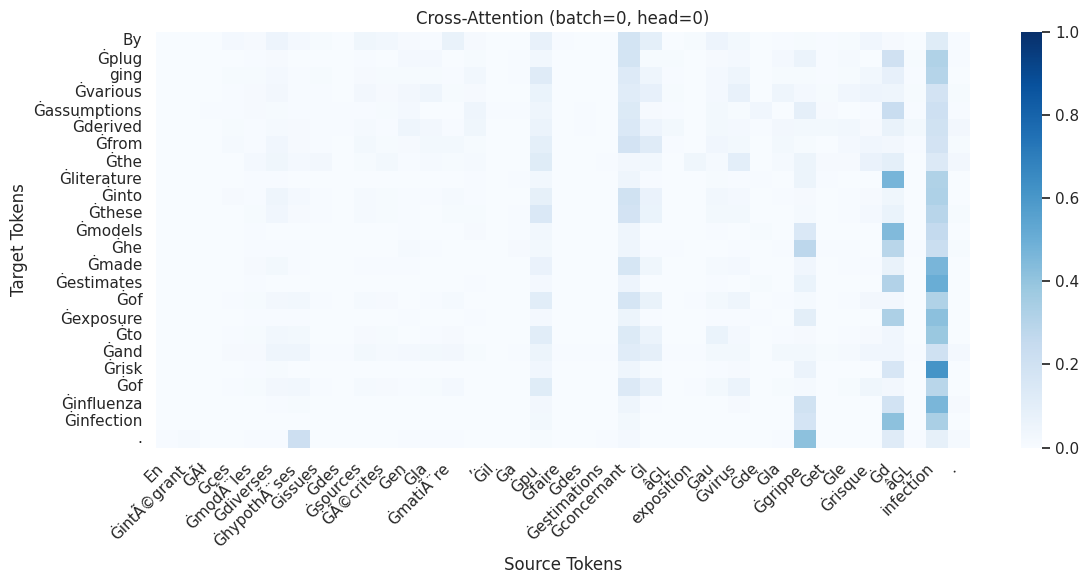

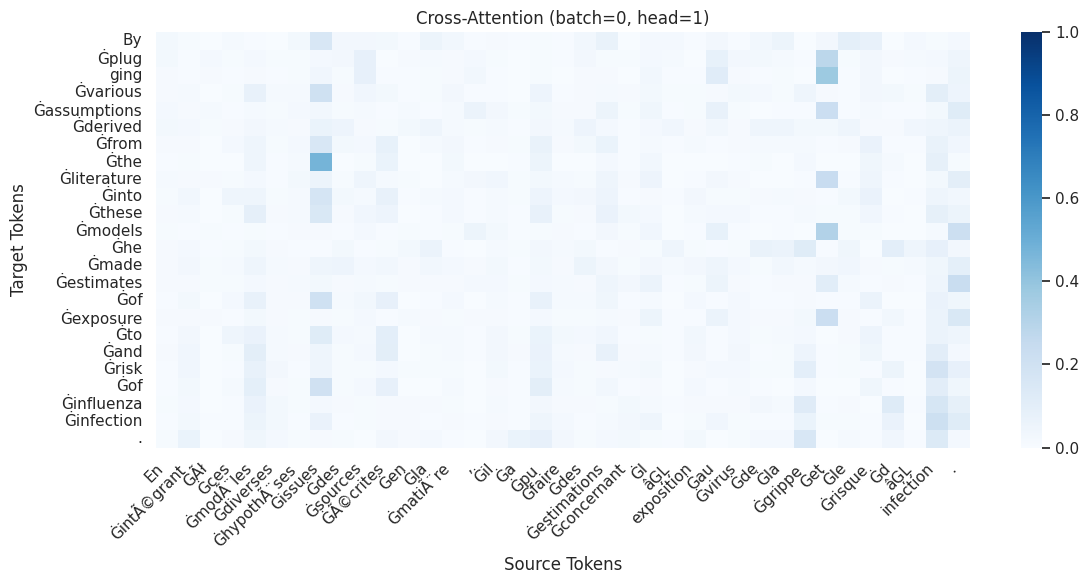

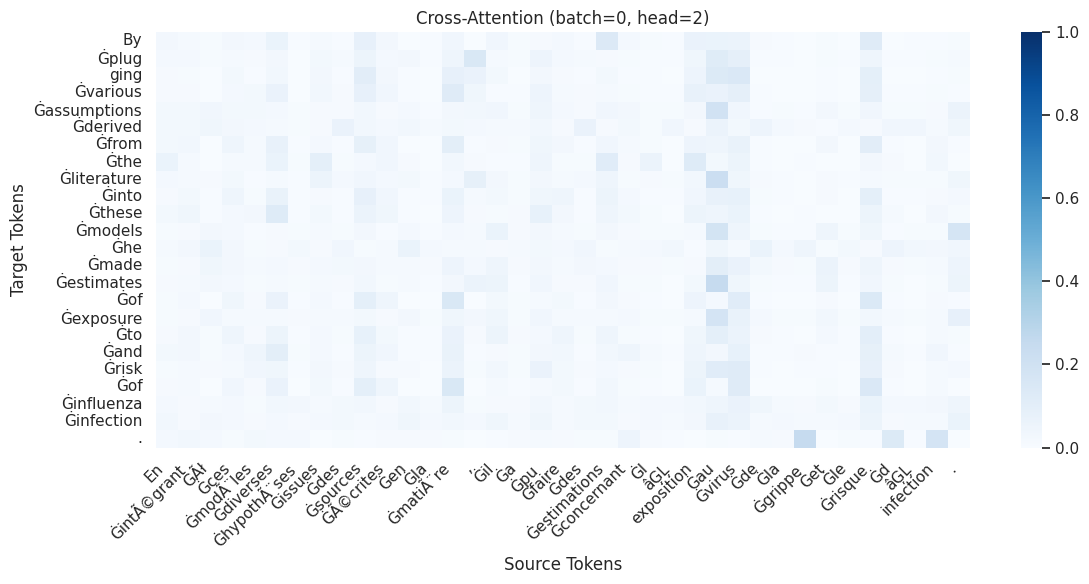

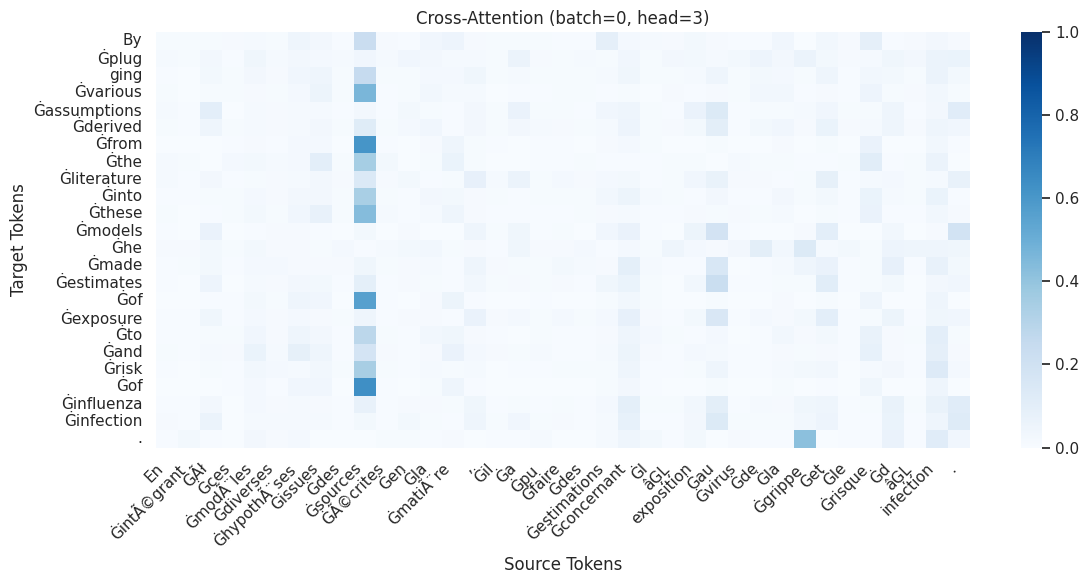

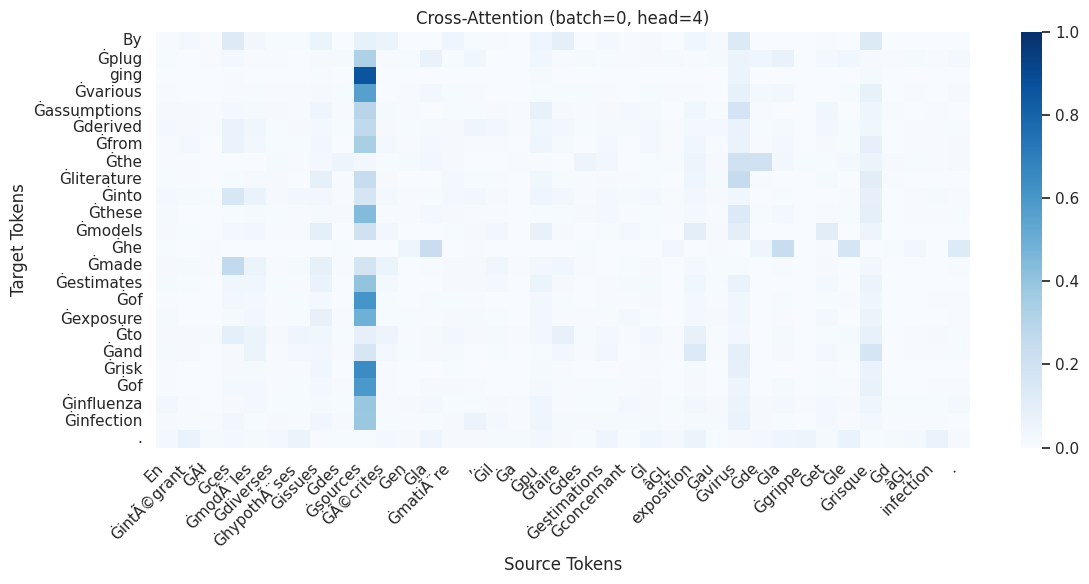

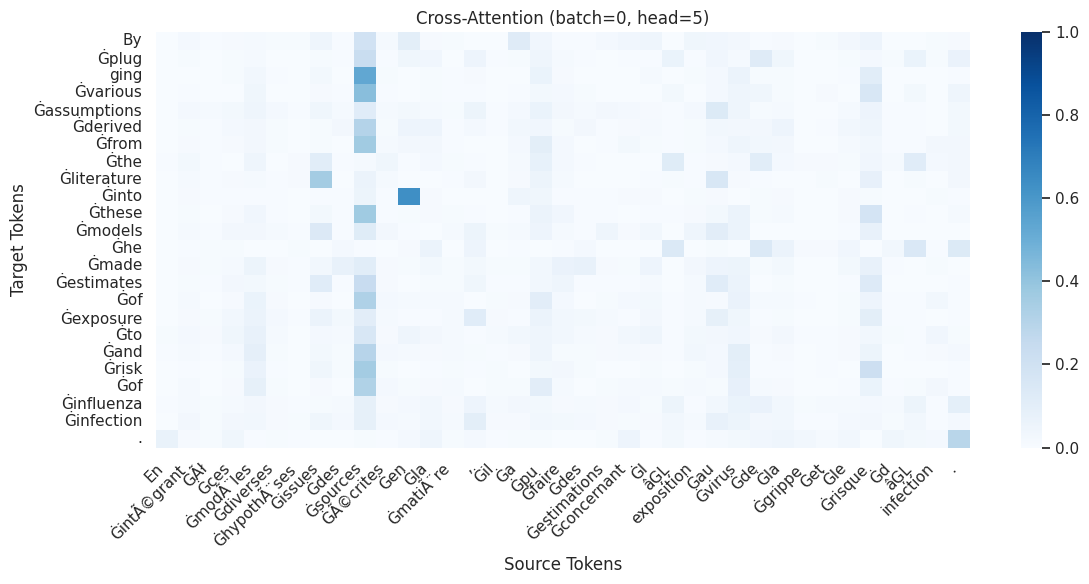

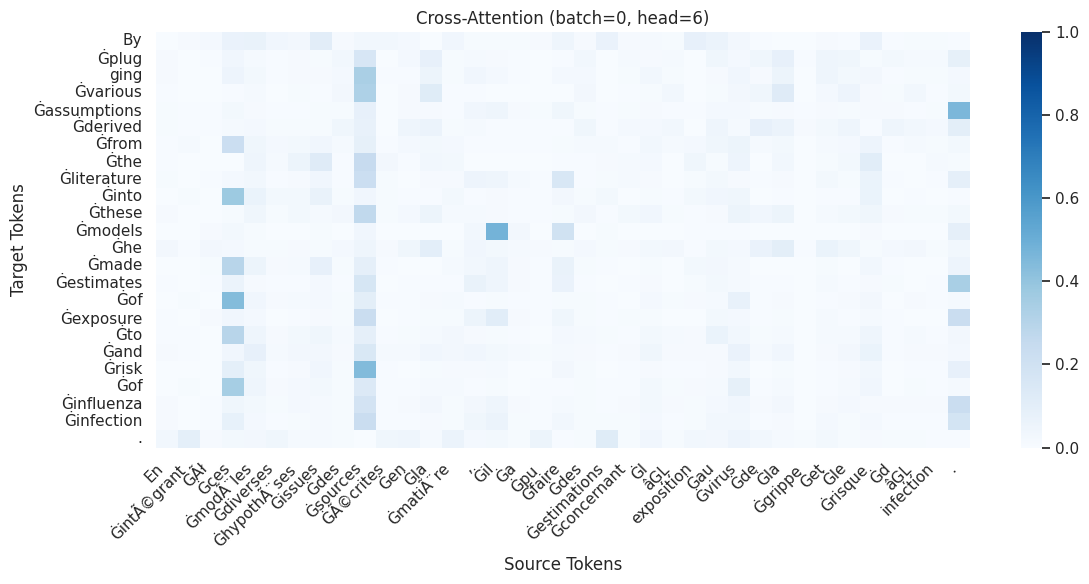

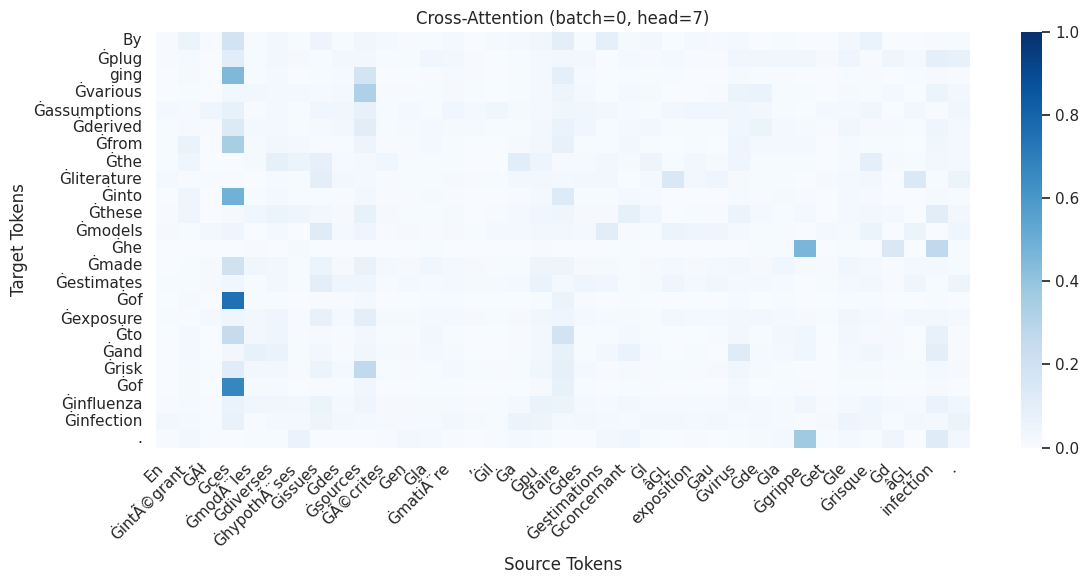

In [22]:
idx = 1
src_val = dataset['train'][idx]['translation']['fr']
tgt_val = dataset['train'][idx]['translation']['en']

print(src_val)
print(tgt_val)


# TODO: Tokenize source and target for attention visualization.
# Requirements:
# - Use padding=True, truncation=True, max_length=max_len, return_tensors='pt'.
# - Move tensors to device.
src_tokens_val = hf_tokenizer(
    src_val,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=max_len
).to(device)
tgt_tokens_val = hf_tokenizer(
    tgt_val,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=max_len
).to(device)

print(src_tokens_val["input_ids"].shape)
print(tgt_tokens_val["input_ids"].shape)

# Run the model
model.eval()
with torch.no_grad():
    logits, attn_weights = model(
        src=src_tokens_val['input_ids'],
        tgt=tgt_tokens_val['input_ids'],
        src_mask=src_tokens_val['attention_mask'],
        tgt_mask=tgt_tokens_val['attention_mask']
    )

# TODO: convert IDs back to token strings for plotting axis labels
src_tokens = hf_tokenizer.convert_ids_to_tokens(src_tokens_val["input_ids"][0])
tgt_tokens = hf_tokenizer.convert_ids_to_tokens(tgt_tokens_val["input_ids"][0])

# Visualize the attention weights
for i in range(num_heads):
    visualize_cross_attention(
        attn_weights=attn_weights,
        source_tokens=src_tokens,
        target_tokens=tgt_tokens,
        batch_idx=0,
        head_idx=i
    )


## Congrats! You can now train a simple machine translator by your own ;)